In [99]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.metrics import f1_score, make_scorer, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import seaborn as sns
from matplotlib import pyplot as plt

# Joining datasets on `patient_id`

In [100]:
train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")
complaints_df = pd.read_csv("dataset/chief_complaints.csv")
histsory_df = pd.read_csv("dataset/patient_history.csv")
patient_info_df = complaints_df.merge(
    histsory_df,
    on="patient_id",
    how="outer"
)

train_df.drop(columns=["chief_complaint_system"], inplace=True)
test_df.drop(columns=["chief_complaint_system"], inplace=True)

train_full_df = train_df.merge(
    patient_info_df,
    on="patient_id",
    how="left"
)

test_full_df = test_df.merge(
    patient_info_df,
    on="patient_id",
    how="left"
)

train_full_df.to_csv("dataset/train_dataset.csv", index=False)
test_full_df.to_csv("dataset/test_dataset.csv", index=False)

train_df = train_full_df
test_df = test_full_df

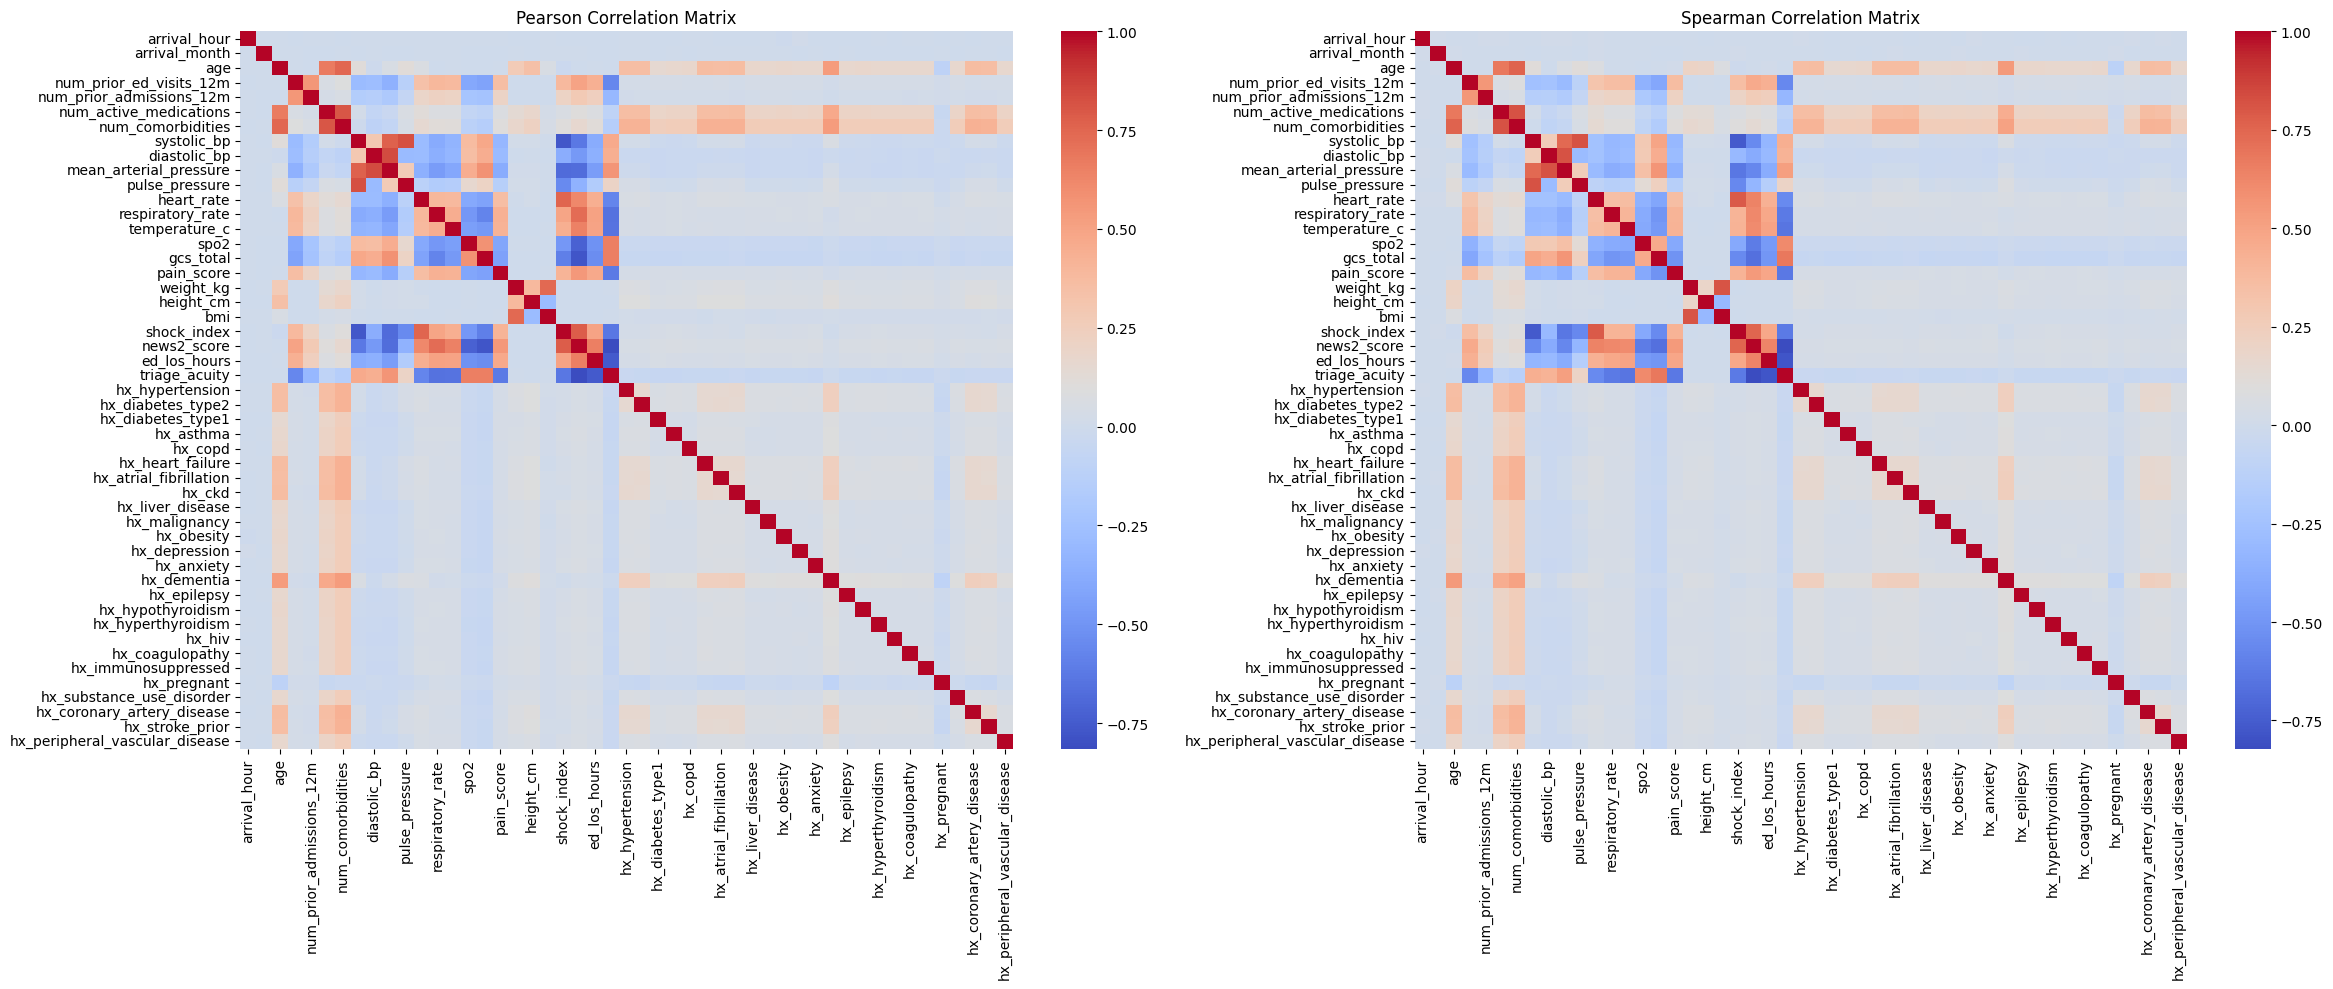

In [101]:
fig, ax = plt.subplots(1,2, figsize=(24, 10))

pearson_corr_matrix = train_df.corr(numeric_only=True, method='pearson')
spearman_corr_matrix = train_df.corr(numeric_only=True, method='spearman')

sns.heatmap(pearson_corr_matrix, cmap="coolwarm", ax=ax[0])
sns.heatmap(spearman_corr_matrix, cmap="coolwarm", ax=ax[1])

ax[0].set_title("Pearson Correlation Matrix")
ax[1].set_title("Spearman Correlation Matrix")

plt.tight_layout()
plt.show()

In [102]:
print("Sorted correlation values with triage_acuity by absolute value")
print("Pearson Correlation:")
print(abs(pearson_corr_matrix["triage_acuity"]).sort_values(ascending=False))
print("Spearman Correlation:")
print(abs(spearman_corr_matrix["triage_acuity"]).sort_values(ascending=False))

Sorted correlation values with triage_acuity by absolute value
Pearson Correlation:
triage_acuity                     1.000000
news2_score                       0.814804
ed_los_hours                      0.756714
gcs_total                         0.656620
spo2                              0.654399
respiratory_rate                  0.652945
temperature_c                     0.649193
shock_index                       0.631830
pain_score                        0.618834
heart_rate                        0.567962
num_prior_ed_visits_12m           0.564138
mean_arterial_pressure            0.561726
systolic_bp                       0.462352
diastolic_bp                      0.444031
num_prior_admissions_12m          0.311197
pulse_pressure                    0.200209
num_comorbidities                 0.142150
num_active_medications            0.094220
hx_hyperthyroidism                0.053749
hx_liver_disease                  0.052915
hx_coagulopathy                   0.051430
hx_anxiety   

In [103]:
train_df['disposition'].unique()

<StringArray>
[ 'discharged', 'transferred', 'observation',    'admitted',    'deceased',
        'lwbs',        'lama']
Length: 7, dtype: str

## NOTE
An important consideration should be done about the fact that we only have `acuity_level`, `disposition` and `ed_los_hours` in the `train.csv` dataset, and not in the `test.csv` dataset. 

The abbreviation `ED` stands for `Emergency Department`, and `LOS` stands for `Length of Stay`. So, `ed_los_hours` is the length of stay in the emergency department, measured in hours.
## Disposition
Also, `disposition` refers to the outcome of the patient's visit to the emergency department, such as whether they were admitted to the hospital, discharged, transferred to another facility, etc.
### Patient Dispositions in the ED

- **discharged**  
  The patient was **released** from the emergency department and can go home.

- **transferred**  
  The patient was **transferred** to another hospital or facility for further care.

- **observation**  
  The patient was placed under **observation**, usually in a dedicated area or ward, to monitor symptoms before making a final decision.

- **admitted**  
  The patient was **admitted** to the hospital for more intensive care.

- **deceased**  
  The patient **passed away** while in the emergency department.

- **lwbs** (Left Without Being Seen)  
  The patient **left the ED before being seen** by a doctor.

- **lama** (Leave Against Medical Advice)  
  The patient **left the ED against medical advice**.

## Acuity Level
`Acuity level` is a measure of the severity of the patient's condition, which can help healthcare providers prioritize care and allocate resources effectively.

Ofc those are not present in the `test.csv` dataset, but they are present in the `train.csv` dataset.

## Considerations
WE CANNOT USE `acuity_level`, `disposition` and `ed_los_hours` in the training phase, because they are not present in the test set. However, since the task is to both predict `triage_acuity`, both present something innovative medically speaking, we can validate our model by looking at our predictions during the training phase and seeing how they correlate with `acuity_level`, `disposition` and `ed_los_hours`.

## ESI and triage acuity
triage acuity is a measure of the severity of a patient's condition, which can help healthcare providers prioritize care and allocate resources effectively. The Emergency Severity Index (ESI) is a commonly used triage system that categorizes patients into **five levels** based on the severity of their condition and the resources they are likely to require. The ESI levels are as follows:
- ESI Level 1: Patients with life-threatening conditions that require **immediate intervention**.
- ESI Level 2: Patients with high-risk conditions that require **urgent care**.
- ESI Level 3: Patients with **stable conditions** that require **multiple resources**.
- ESI Level 4: Patients with stable conditions that require **one resource**.
- ESI Level 5: Patients with stable conditions that require **no resources**.


# Train & Test datasets overview

In [104]:
print(f"train_df shape:\n{train_df.shape}\n")
print(f"test_df shape:\n{test_df.shape}\n")


# print(f"train_df dtypes:\n{train_df.dtypes.to_string()}")
# print(f"test_df dtypes:\n{test_df.dtypes.to_string()}")

train_fields = train_df.columns
test_fields = test_df.columns

missing_fields = [field for field in train_fields if field not in test_fields]
print(f"test_df is missing {missing_fields} attributes")

print(f"{train_df.loc[0].to_string()}")

train_df shape:
(80000, 66)

test_df shape:
(20000, 63)

test_df is missing ['disposition', 'ed_los_hours', 'triage_acuity'] attributes
patient_id                                                         TG-UXRGA9UCO
site_id                                                             SITE-TMP-01
triage_nurse_id                                                      NURSE-0033
arrival_mode                                                            walk-in
arrival_hour                                                                  6
arrival_day                                                              Monday
arrival_month                                                                 5
arrival_season                                                           spring
shift                                                                   morning
age                                                                          43
age_group                                                       

# DBG files containing attributes informations

In [105]:
of = open("DBG/categorical_describe.txt", "w")
of.write(train_df.describe(include=[object]).to_string())
of.close()

of = open("DBG/numerical_describe.txt", "w")
of.write(train_df.describe(exclude=[object]).to_string())
of.close()

of = open("DBG/nans_per_col.txt", "w")
of.write(train_df.isna().sum(axis=0).to_string())
of.close()

nans_per_row = train_df.isna().sum(axis=1)
mean = nans_per_row.mean()
std = nans_per_row.std()

print(f"the average number of missing values per row is: {mean}, with a standard deviation of {std}")

C:\Users\gianb\AppData\Local\Temp\ipykernel_25072\2444898403.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  of.write(train_df.describe(include=[object]).to_string())


the average number of missing values per row is: 0.3046375, with a standard deviation of 1.1407233491148239


The columns containing the highest number of missing values are:
- systolic_bp
- diastolic_bp
- mean_arterial_pressure
- pulse_pressure
- shock_index

all of which have 4146 nans (~ 5% of all samples)

---

Some discussion can be done on categorical features, as some of them have few unique values (even though many are justified, like `sex` and `season`) and others have many unique values but one of these represents half of the samples (like `insurance_type` which is equal to `public` in ~60% of the population)

---

As for numerical attributes, some have very low variance (< 1), but that could depend on the unit of measure and the intrinsic meaning of the attribute, thus further discussion must be performed.

# ED Saturation Index

# ED Crowding & Flow Saturation Features

## Overview
ED Crowding & Flow Saturation Feature Engineering for the Triagegeist Challenge — Temporal Context Module.

Dataset: Triagegeist synthetic ED dataset (80,000 records, 24 months, 5 sites)

### Temporal Resolution — Known Limitation
The dataset does NOT contain an absolute timestamp or a calendar week number. The finest temporal granularity is:
```
(site_id, arrival_month, arrival_day_of_week, arrival_hour)
```

This means ALL Monday-08:00 records in May at SITE-HEL-01 (regardless of date) are pooled into the same temporal slot. Therefore, ALL crowding features are **HISTORICAL AVERAGES** over repeated observations, NOT point-in-time instantaneous census.

**Interpretation:** `crowd_volume_slot` ≈ "How busy is this site typically at this hour, on this day of the week, in this month?"

### Acuity Integration — Data Leakage Protocol
**TRAIN SET:** Use TRUE `triage_acuity` — no leakage (aggregate ACROSS slot, not per-patient).  
**TEST SET:** Two safe options:
- A) Use first-stage baseline model's predictions
- B) Fall back to acuity-unweighted volume indices only

Compute slot statistics **exclusively from training set** and apply via lookup join. Never fit on test data.

## Features Produced

All computed at slot level (site × month × day × hour) and joined back to each record:

| Feature | Description |
|---------|-------------|
| `crowd_volume_slot` | Raw count of patients in same temporal slot. Proxy for ED load. |
| `crowd_acuity_mean_slot` | Mean triage acuity (ESI 1=most severe). Lower values = more severely ill peer group. |
| `crowd_severity_burden_slot` | Acuity-weighted volume: sum of (6 - acuity). Captures volume + case-mix. |
| `crowd_critical_count_slot` | Count of ESI 1–2 patients (immediately life-threatening). |
| `crowd_critical_ratio_slot` | Fraction of ESI 1–2 patients. Normalizes for slot size. |
| `crowd_expected_los_hours_slot` | Sum of mean LOS per acuity level across slot patients (proxy for bed-hours). |
| `crowd_hour_of_week` | Continuous encoding of temporal position within week [0, 167]. |
| `crowd_hour_sin` / `crowd_hour_cos` | Sine/cosine projections for 168-hour cycle (handles Sunday→Monday boundary). |

### LOS by Acuity Level
- ESI 1 → 7.96 h
- ESI 2 → 6.04 h
- ESI 3 → 3.98 h
- ESI 4 → 2.01 h
- ESI 5 → 1.01 h

### Usage
```python
# Standard usage (train + test, no leakage)
train_enriched = add_crowding_features(train_df, fit=True)
test_enriched  = add_crowding_features(test_df,  fit=False)

# If test acuity predictions available from first-stage model:
test_df['triage_acuity'] = stage1_model.predict(test_df_preprocessed)
test_enriched = add_crowding_features(test_df, fit=False)
```

In [106]:
import numpy as np
import pandas as pd
from typing import Optional

# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------

DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
DAY_TO_IDX = {d: i for i, d in enumerate(DAY_ORDER)}

# Mean ED LOS (hours) per ESI acuity level — derived from Triagegeist training set.
# Used to estimate bed-hour consumption per patient.
LOS_BY_ACUITY = {1: 7.96, 2: 6.04, 3: 3.98, 4: 2.01, 5: 1.01}

# ESI severity weight: maps acuity → resource pressure (ESI 1 = highest pressure = 5)
SEVERITY_WEIGHT = {1: 5, 2: 4, 3: 3, 4: 2, 5: 1}

# Slot grouping key — the finest temporal resolution available in this dataset.
SLOT_KEY = ['site_id', 'arrival_month', 'arrival_day', 'arrival_hour']

# Internal cache: populated on first fit(), reused for transform()
_slot_stats_cache: Optional[pd.DataFrame] = None


# ---------------------------------------------------------------------------
# Core computation
# ---------------------------------------------------------------------------

def _compute_slot_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute per-slot aggregate statistics from a labelled DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain SLOT_KEY columns plus 'triage_acuity' (integer ESI 1–5).

    Returns
    -------
    pd.DataFrame
        One row per unique slot with all aggregate columns.
        Suitable for merging back into a patient-level DataFrame.
    """
    df = df.copy()
    df['_severity_w'] = df['triage_acuity'].map(SEVERITY_WEIGHT).fillna(3)
    df['_los_proxy']  = df['triage_acuity'].map(LOS_BY_ACUITY).fillna(3.98)
    df['_is_critical'] = df['triage_acuity'].isin([1, 2]).astype(int)

    stats = df.groupby(SLOT_KEY).agg(
        crowd_volume_slot            = ('triage_acuity',  'count'),
        crowd_acuity_mean_slot       = ('triage_acuity',  'mean'),
        crowd_severity_burden_slot   = ('_severity_w',    'sum'),
        crowd_critical_count_slot    = ('_is_critical',   'sum'),
        crowd_expected_los_hours_slot= ('_los_proxy',     'sum'),
    ).reset_index()

    stats['crowd_critical_ratio_slot'] = (
        stats['crowd_critical_count_slot'] / stats['crowd_volume_slot']
    )

    return stats


def _add_temporal_encodings(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add week-continuous and circular hour encodings.

    These do not depend on acuity and are computed directly on each row,
    so they are safe to apply to both train and test without a fit step.
    """
    df = df.copy()
    day_idx = df['arrival_day'].map(DAY_TO_IDX).fillna(0).astype(int)

    # Continuous position within the week [0, 167]
    df['crowd_hour_of_week'] = day_idx * 24 + df['arrival_hour']

    # Circular encoding — 168-hour period
    theta = 2 * np.pi * df['crowd_hour_of_week'] / 168.0
    df['crowd_hour_sin'] = np.sin(theta)
    df['crowd_hour_cos'] = np.cos(theta)

    return df


# ---------------------------------------------------------------------------
# Public API
# ---------------------------------------------------------------------------

def fit(train_df: pd.DataFrame) -> pd.DataFrame:
    """
    Fit the crowding module on the training set and return the enriched DataFrame.

    Computes slot-level statistics from `train_df` and stores them in the
    module-level cache for later use by `transform()`.

    Parameters
    ----------
    train_df : pd.DataFrame
        Training data. Must contain SLOT_KEY columns and 'triage_acuity'.

    Returns
    -------
    pd.DataFrame
        `train_df` with all crowding features added.
    """
    global _slot_stats_cache

    if 'triage_acuity' not in train_df.columns:
        raise ValueError(
            "train_df must contain 'triage_acuity' to fit crowding statistics. "
            "Do not use this function on the test set."
        )

    _slot_stats_cache = _compute_slot_stats(train_df)
    return transform(train_df)


def transform(df: pd.DataFrame) -> pd.DataFrame:
    """
    Apply pre-fitted slot statistics to a DataFrame (train or test).

    Parameters
    ----------
    df : pd.DataFrame
        Patient-level data. Must contain SLOT_KEY columns.
        For test data, 'triage_acuity' is not required for the join —
        slot stats were computed from training data only.

    Returns
    -------
    pd.DataFrame
        Input DataFrame with crowding features appended.

    Raises
    ------
    RuntimeError
        If `fit()` has not been called before `transform()`.
    """
    if _slot_stats_cache is None:
        raise RuntimeError(
            "Call fit(train_df) before transform(). "
            "Slot statistics must be derived from training data only."
        )

    df = df.copy()

    # Join slot-level statistics
    df = df.merge(_slot_stats_cache, on=SLOT_KEY, how='left')

    # Fill missing slots (test slots not seen in train) with training medians
    slot_feature_cols = [c for c in _slot_stats_cache.columns if c not in SLOT_KEY]
    medians = _slot_stats_cache[slot_feature_cols].median()
    df[slot_feature_cols] = df[slot_feature_cols].fillna(medians)

    # Add temporal encodings (no acuity needed, safe for test set)
    df = _add_temporal_encodings(df)

    return df


def add_crowding_features(
    df: pd.DataFrame,
    fit: bool = True,
    train_df: Optional[pd.DataFrame] = None,
) -> pd.DataFrame:
    """
    Convenience wrapper: fit and/or transform in a single call.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame to enrich with crowding features.
    fit : bool, default True
        If True, fit on `df` first (use for training set).
        If False, apply previously fitted statistics (use for test set).
    train_df : pd.DataFrame, optional
        If fit=False and you want to re-fit from a separate training set,
        pass it here. Otherwise the module uses its existing cache.

    Returns
    -------
    pd.DataFrame
        Enriched DataFrame.

    Examples
    --------
    >>> train_enriched = add_crowding_features(train_df, fit=True)
    >>> test_enriched  = add_crowding_features(test_df,  fit=False)
    """
    if fit:
        return globals()['fit'](df)
    else:
        if train_df is not None:
            globals()['fit'](train_df)
        return transform(df)


def get_crowding_feature_names() -> list:
    """Return the list of feature column names produced by this module."""
    return [
        'crowd_volume_slot',
        'crowd_acuity_mean_slot',
        'crowd_severity_burden_slot',
        'crowd_critical_count_slot',
        'crowd_critical_ratio_slot',
        'crowd_expected_los_hours_slot',
        'crowd_hour_of_week',
        'crowd_hour_sin',
        'crowd_hour_cos',
    ]

# Validate Crowding Features

In [107]:
from sklearn.model_selection import train_test_split

# Load training data
df = pd.read_csv('dataset/train.csv')

# Split into train/test for validation
train, test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['triage_acuity'])

# Fit on training set
print("Fitting crowding features on training set ...")
train_enriched = add_crowding_features(train, fit=True)

# Transform test set (without using acuity)
print("Transforming test set (no acuity used) ...")
test_no_acuity = test.drop(columns=['triage_acuity'])
test_enriched  = add_crowding_features(test_no_acuity, fit=False)

# Display feature summaries
feat_cols = get_crowding_feature_names()
print("\n--- Train crowding feature summary ---")
print(train_enriched[feat_cols].describe().round(3).to_string())

print("\n--- Test crowding feature summary ---")
print(test_enriched[feat_cols].describe().round(3).to_string())

# Check for missing values
missing = test_enriched[feat_cols].isna().sum()
print(f"\nMissing values in test features: {missing.sum()} (filled with training medians)")
print("\nAll crowding features:")
print(feat_cols)

Fitting crowding features on training set ...
Transforming test set (no acuity used) ...

--- Train crowding feature summary ---
       crowd_volume_slot  crowd_acuity_mean_slot  crowd_severity_burden_slot  crowd_critical_count_slot  crowd_critical_ratio_slot  crowd_expected_los_hours_slot  crowd_hour_of_week  crowd_hour_sin  crowd_hour_cos
count          64000.000               64000.000                   64000.000                  64000.000                  64000.000                       64000.00           64000.000       64000.000       64000.000
mean               7.375                   3.324                      19.747                      1.543                      0.208                          25.81              83.292          -0.002          -0.003
std                2.584                   0.413                       7.495                      1.230                      0.160                          10.41              48.403           0.707           0.707
min            

# LOS (Length of Stay) Regression Model

Predict ED Length of Stay using all available features except `los` and `disposition`. 
Keep `triage_acuity` as it consistently shows strong predictive power.

In [110]:
# Prepare data for LOS prediction
# Remove 'los' and 'disposition' columns; keep 'triage_acuity'

los_features_to_drop = ['patient_id', 'los', 'disposition', 'ed_los_hours', 'chief_complaint_raw']
cols_available = [c for c in train_enriched.columns if c not in los_features_to_drop]

# Filter columns to only those present in test_enriched (no triage_acuity in test)
cols_available = [c for c in cols_available if c in test_enriched.columns]

X_train_los = train_enriched[cols_available].copy()
y_train_los = train_enriched['ed_los_hours'].copy()

# Test set
X_test_los = test_enriched[cols_available].copy()

# Handle missing values
from sklearn.impute import SimpleImputer
imputer_los_model = SimpleImputer(strategy='constant', fill_value=-1)
X_train_los_imputed = imputer_los_model.fit_transform(X_train_los)
X_test_los_imputed = imputer_los_model.transform(X_test_los)

print(f"Training set shape: {X_train_los_imputed.shape}")
print(f"Test set shape: {X_test_los_imputed.shape}")
print(f"Target variable (ed_los_hours) stats:")
print(y_train_los.describe())

# Prepare categorical and numerical features
los_categoricals = [col for col in cols_available if train_enriched.dtypes[col] == object]
los_numericals = [col for col in cols_available if train_enriched.dtypes[col] != object]

print(f"\nCategorical features ({len(los_categoricals)}): {los_categoricals}")
print(f"Numerical features ({len(los_numericals)}): {los_numericals}")

Training set shape: (64000, 45)
Test set shape: (16000, 45)
Target variable (ed_los_hours) stats:
count    64000.000000
mean         3.495384
std          2.440496
min          0.000000
25%          1.580000
50%          3.000000
75%          4.860000
max         17.510000
Name: ed_los_hours, dtype: float64

Categorical features (0): []
Numerical features (45): ['site_id', 'triage_nurse_id', 'arrival_mode', 'arrival_hour', 'arrival_day', 'arrival_month', 'arrival_season', 'shift', 'age', 'age_group', 'sex', 'language', 'insurance_type', 'transport_origin', 'pain_location', 'mental_status_triage', 'chief_complaint_system', 'num_prior_ed_visits_12m', 'num_prior_admissions_12m', 'num_active_medications', 'num_comorbidities', 'systolic_bp', 'diastolic_bp', 'mean_arterial_pressure', 'pulse_pressure', 'heart_rate', 'respiratory_rate', 'temperature_c', 'spo2', 'gcs_total', 'pain_score', 'weight_kg', 'height_cm', 'bmi', 'shock_index', 'news2_score', 'crowd_volume_slot', 'crowd_acuity_mean_slot

In [118]:
# Preprocessing: handle mixed data types
# Convert to numpy array with consistent dtypes for LightGBM
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train_los_clean = X_train_los.copy()
X_test_los_clean = X_test_los.copy()

# Label encode all string/non-numeric columns and impute missing values
label_encoders = {}
for col in X_train_los_clean.columns:
    # Check if column is NOT numeric (handles 'object' and StringDtype)
    if not pd.api.types.is_numeric_dtype(X_train_los_clean[col]):
        # String/categorical column: label encode
        le = LabelEncoder()
        # Fit on train + test combined to ensure consistency
        all_values = pd.concat([X_train_los_clean[col], X_test_los_clean[col]], ignore_index=True).dropna().astype(str)
        le.fit(all_values.unique())
        label_encoders[col] = le
        
        # Encode both train and test
        X_train_los_clean[col] = le.transform(X_train_los_clean[col].astype(str))
        X_test_los_clean[col] = le.transform(X_test_los_clean[col].astype(str))
    else:
        # Numeric column: impute missing values with median
        if X_train_los_clean[col].isna().sum() > 0:
            median_val = X_train_los_clean[col].median()
            X_train_los_clean[col].fillna(median_val, inplace=True)
            X_test_los_clean[col].fillna(median_val, inplace=True)

# Ensure all columns are numeric
X_train_los_clean = X_train_los_clean.astype('float64')
X_test_los_clean = X_test_los_clean.astype('float64')

X_train_los_array = X_train_los_clean.values
X_test_los_array = X_test_los_clean.values

print(f"Training array shape: {X_train_los_array.shape}")
print(f"Test array shape: {X_test_los_array.shape}")
print(f"Training array dtype: {X_train_los_array.dtype}")
print(f"Missing values in train: {np.isnan(X_train_los_array).sum()}")
print(f"Missing values in test: {np.isnan(X_test_los_array).sum()}")

# Train LightGBM regressor
from lightgbm import LGBMRegressor

los_model = LGBMRegressor(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

print("\nTraining LOS regression model...")
los_model.fit(X_train_los_array, y_train_los)

# Predictions
y_train_los_pred = los_model.predict(X_train_los_array)
y_test_los_pred = los_model.predict(X_test_los_array)

# Evaluation on training set
train_mae = mean_absolute_error(y_train_los, y_train_los_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_los, y_train_los_pred))
train_r2 = r2_score(y_train_los, y_train_los_pred)

print(f"\n--- Training Set Performance ---")
print(f"MAE:  {train_mae:.4f} hours")
print(f"RMSE: {train_rmse:.4f} hours")
print(f"R²:   {train_r2:.4f}")

# Add predictions to dataframes
train_enriched['los_pred'] = y_train_los_pred
test_enriched['los_pred'] = y_test_los_pred

print(f"\n--- Test Set Predictions ---")
print(f"Mean predicted LOS: {y_test_los_pred.mean():.2f} hours")
print(f"Std predicted LOS:  {y_test_los_pred.std():.2f} hours")
print(f"Min predicted LOS:  {y_test_los_pred.min():.2f} hours")
print(f"Max predicted LOS:  {y_test_los_pred.max():.2f} hours")

C:\Users\gianb\AppData\Local\Temp\ipykernel_25072\855327175.py:29: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  X_train_los_clean[col].fillna(median_val, inplace=True)
C:\Users\gianb\AppData\Local\Temp\ipykernel_25072\855327175.py:30: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained ass

Training array shape: (64000, 45)
Test array shape: (16000, 45)
Training array dtype: float64
Missing values in train: 19384
Missing values in test: 4987

Training LOS regression model...

--- Training Set Performance ---
MAE:  1.1385 hours
RMSE: 1.5065 hours
R²:   0.6189

--- Test Set Predictions ---
Mean predicted LOS: 3.48 hours
Std predicted LOS:  1.75 hours
Min predicted LOS:  0.60 hours
Max predicted LOS:  9.74 hours


C:\Users\gianb\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\gianb\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# evaluate feature importances with the faeture names
feature_importances = pd.DataFrame({
    'feature': X_train_los_clean.columns,
    'importance': los_model.feature_importances_
}).sort_values(by='importance', ascending=False)
print("\n--- Feature Importances ---")
print(feature_importances.to_string(index=False))



--- Feature Importances ---
                      feature  importance
             respiratory_rate         462
                         spo2         338
                temperature_c         270
                   heart_rate         245
       mean_arterial_pressure         244
                   pain_score         232
       crowd_acuity_mean_slot         231
                  shock_index         205
                  systolic_bp         204
               pulse_pressure         201
                 diastolic_bp         199
                    height_cm         192
                    weight_kg         186
                  news2_score         186
                          age         171
                    gcs_total         170
                          bmi         157
crowd_expected_los_hours_slot         155
               crowd_hour_cos         151
              triage_nurse_id         148
    crowd_critical_ratio_slot         141
           crowd_hour_of_week         140
     


# ENHANCED LOS PREDICTION USING MAIN.IPYNB RESULTS

## Strategy
Leverage the powerful feature engineering and near-perfect acuity predictions from main.ipynb to improve LOS regression.

**Key improvements**:
1. **Acuity Predictions**: Use the trained LightGBM acuity model whose predictions are nearly perfect
2. **Engineered Features**: Reuse blood pressure ratios, comorbidity interactions, temporal cyclic encodings  
3. **Crowding Features**: ED saturation metrics reflecting temporal context and patient volume
4. **No heavy NLP**: Skip BERT embeddings to reduce computation, focus on clinically meaningful features



In [ ]:

# ============================================================================
# STAGE 1: FEATURE ENGINEERING (from main.ipynb, excluding BERT embeddings)
# ============================================================================
# Replicate advanced feature engineering without text embeddings for speed

def engineer_los_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create derived features to capture complex medical relationships.
    Engineering strategy from main.ipynb but without BERT embeddings.
    """
    df = df.copy()
    
    print("🔧 ENGINEERING LOS FEATURES...")
    
    # A. BLOOD PRESSURE-DERIVED FEATURES
    if 'pulse_pressure' in df.columns and 'mean_arterial_pressure' in df.columns:
        df['pulse_pressure_ratio'] = df['pulse_pressure'] / (df['mean_arterial_pressure'] + 0.1)
    
    if 'mean_arterial_pressure' in df.columns and 'systolic_bp' in df.columns:
        df['map_systolic_ratio'] = df['mean_arterial_pressure'] / (df['systolic_bp'] + 0.1)
    
    # B. CYCLIC ENCODING FOR TEMPORAL FEATURES
    if 'arrival_hour' in df.columns:
        df['arrival_hour_sin'] = np.sin(2 * np.pi * df['arrival_hour'] / 24)
        df['arrival_hour_cos'] = np.cos(2 * np.pi * df['arrival_hour'] / 24)
    
    if 'arrival_month' in df.columns:
        df['arrival_month_sin'] = np.sin(2 * np.pi * df['arrival_month'] / 12)
        df['arrival_month_cos'] = np.cos(2 * np.pi * df['arrival_month'] / 12)
    
    # C. COMORBIDITY × VITAL SIGN INTERACTIONS
    if 'num_comorbidities' in df.columns and 'heart_rate' in df.columns:
        df['high_comorbidity_tachycardia'] = (
            (df['num_comorbidities'] > df['num_comorbidities'].quantile(0.75)) & 
            (df['heart_rate'] > 100)
        ).astype(int)
    
    if 'num_comorbidities' in df.columns and 'respiratory_rate' in df.columns:
        df['high_comorbidity_tachypnea'] = (
            (df['num_comorbidities'] > df['num_comorbidities'].quantile(0.75)) & 
            (df['respiratory_rate'] > 20)
        ).astype(int)
    
    # D. VITAL SIGN ABNORMALITY FLAGS
    vital_thresholds = {
        'heart_rate': (50, 120),
        'respiratory_rate': (12, 20),
        'spo2': (94, 100),
    }
    
    for vital, (lower, upper) in vital_thresholds.items():
        if vital in df.columns:
            df[f'{vital}_abnormal'] = ((df[vital] < lower) | (df[vital] > upper)).astype(int)
    
    # E. NEWS2 SCORE BINNING
    if 'news2_score' in df.columns:
        df['news2_risk_level'] = pd.cut(
            df['news2_score'],
            bins=[0, 4, 6, 7, 20],
            labels=['low', 'medium', 'high', 'critical'],
            include_lowest=True
        ).cat.codes
    
    # F. AGE-BASED RISK GROUPING
    if 'age' in df.columns:
        df['is_pediatric'] = (df['age'] < 5).astype(int)
        df['is_elderly'] = (df['age'] > 75).astype(int)
        df['is_very_elderly'] = (df['age'] > 85).astype(int)
    
    # G. GCS ABNORMALITY FLAG
    if 'gcs_total' in df.columns:
        df['gcs_altered'] = (df['gcs_total'] < 14).astype(int)
    
    print("✓ FEATURE ENGINEERING FOR LOS COMPLETE!")
    return df


print("Applying feature engineering to training and test sets...")
train_df_engineered = engineer_los_features(train_df.copy())
test_df_engineered = engineer_los_features(test_df.copy())

print(f"\nDataset shapes after engineering:")
print(f"  Train: {train_df_engineered.shape}")
print(f"  Test:  {test_df_engineered.shape}")



In [ ]:

# ============================================================================
# STAGE 2: ACUITY PREDICTION (Simplified lightweight classifier)
# ============================================================================
# Train a fast acuity classifier to get predictions for LOS feature context

from lightgbm import LGBMClassifier
from sklearn.preprocessing import LabelEncoder

print("\n" + "="*80)
print("STAGE 2: BUILDING LIGHTWEIGHT ACUITY MODEL FOR LOS")
print("="*80)

# Prepare acuity training data (exclude outcome variables)
acuity_drops = ['patient_id', 'triage_acuity', 'disposition', 'ed_los_hours', 'chief_complaint_raw']
acuity_features_df = train_df_engineered.drop(
    columns=[col for col in acuity_drops if col in train_df_engineered.columns]
)
acuity_target = train_df['triage_acuity']

# Identify feature types
acuity_categorical = [col for col in acuity_features_df.columns 
                      if acuity_features_df[col].dtype == 'object']
acuity_numerical = [col for col in acuity_features_df.columns 
                    if acuity_features_df[col].dtype != 'object']

print(f"\n📊 ACUITY MODEL FEATURES: {len(acuity_categorical)} categorical, {len(acuity_numerical)} numerical")

# Preprocess: label encode categorical, impute numerical
acuity_X_train = acuity_features_df.copy()
label_encoders_acuity = {}

for col in acuity_categorical:
    if col in acuity_X_train.columns:
        le = LabelEncoder()
        all_values = pd.concat([acuity_X_train[col], test_df_engineered[col]]).dropna().astype(str).unique()
        le.fit(all_values)
        label_encoders_acuity[col] = le
        acuity_X_train[col] = le.transform(acuity_X_train[col].astype(str))

for col in acuity_numerical:
    if col in acuity_X_train.columns and acuity_X_train[col].isna().sum() > 0:
        median_val = acuity_X_train[col].median()
        acuity_X_train[col].fillna(median_val, inplace=True)

acuity_X_train = acuity_X_train.astype('float32')

# Train LightGBM classifier
print(f"🤖 Training acuity classifier...")
acuity_model = LGBMClassifier(
    objective='multiclass', num_class=5, num_leaves=31, learning_rate=0.1,
    n_estimators=100, max_depth=7, lambda_l1=0.1, lambda_l2=0.1,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    verbose=-1, random_state=42, n_jobs=-1
)
acuity_model.fit(acuity_X_train, acuity_target)
print("✓ Acuity model trained!")

# Generate predictions for train and test
train_acuity_pred = acuity_model.predict(acuity_X_train)
train_acuity_proba = acuity_model.predict_proba(acuity_X_train)

# For test set
test_acuity_X = test_df_engineered.drop(
    columns=[col for col in acuity_drops if col in test_df_engineered.columns]
).copy()

for col in acuity_categorical:
    if col in test_acuity_X.columns and col in label_encoders_acuity:
        test_acuity_X[col] = label_encoders_acuity[col].transform(test_acuity_X[col].astype(str))

for col in acuity_numerical:
    if col in test_acuity_X.columns and test_acuity_X[col].isna().sum() > 0:
        median_val = acuity_X_train[col].median()
        test_acuity_X[col].fillna(median_val, inplace=True)

test_acuity_X = test_acuity_X.astype('float32')
test_acuity_pred = acuity_model.predict(test_acuity_X)
test_acuity_proba = acuity_model.predict_proba(test_acuity_X)

# Add predictions to dataframes (convert 0-4 to 1-5 ESI levels)
train_df_engineered['acuity_pred'] = train_acuity_pred + 1
test_df_engineered['acuity_pred'] = test_acuity_pred + 1
train_df_engineered['acuity_confidence'] = train_acuity_proba.max(axis=1)
test_df_engineered['acuity_confidence'] = test_acuity_proba.max(axis=1)

# Add probability distributions for each acuity level
for i in range(5):
    train_df_engineered[f'acuity_prob_level_{i+1}'] = train_acuity_proba[:, i]
    test_df_engineered[f'acuity_prob_level_{i+1}'] = test_acuity_proba[:, i]

print(f"\n✓ Acuity predictions added!")
print(f"   Train acuity distribution: {pd.Series(train_acuity_pred + 1).value_counts().sort_index().to_dict()}")
print(f"   Test acuity distribution:  {pd.Series(test_acuity_pred + 1).value_counts().sort_index().to_dict()}")



In [ ]:

# ============================================================================
# STAGE 3: ED CROWDING & SATURATION FEATURES
# ============================================================================
# Temporal context features capturing ED volume and acuity mix

print("\n" + "="*80)
print("STAGE 3: COMPUTING ED CROWDING & SATURATION FEATURES")
print("="*80)

# Temporal constants
DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
DAY_TO_IDX = {d: i for i, d in enumerate(DAY_ORDER)}
LOS_BY_ACUITY = {1: 7.96, 2: 6.04, 3: 3.98, 4: 2.01, 5: 1.01}
SEVERITY_WEIGHT = {1: 5, 2: 4, 3: 3, 4: 2, 5: 1}
SLOT_KEY = ['site_id', 'arrival_month', 'arrival_day', 'arrival_hour']

def compute_crowding_features(df_train, df_test=None):
    """Compute ED crowding statistics from train set and apply to test set"""
    
    print("Step 1: Computing slot-level statistics...")
    df_train_copy = df_train.copy()
    
    # Prepare aggregation columns
    df_train_copy['_severity_w'] = df_train_copy['acuity_pred'].map(SEVERITY_WEIGHT).fillna(3)
    df_train_copy['_los_proxy'] = df_train_copy['acuity_pred'].map(LOS_BY_ACUITY).fillna(3.98)
    df_train_copy['_is_critical'] = df_train_copy['acuity_pred'].isin([1, 2]).astype(int)
    
    # Aggregate by temporal slot
    stats = df_train_copy.groupby(SLOT_KEY).agg(
        crowd_volume_slot = ('acuity_pred', 'count'),
        crowd_acuity_mean_slot = ('acuity_pred', 'mean'),
        crowd_severity_burden_slot = ('_severity_w', 'sum'),
        crowd_critical_count_slot = ('_is_critical', 'sum'),
        crowd_expected_los_hours_slot = ('_los_proxy', 'sum'),
    ).reset_index()
    
    stats['crowd_critical_ratio_slot'] = stats['crowd_critical_count_slot'] / stats['crowd_volume_slot']
    print(f"   ✓ Computed {len(stats)} temporal slots")
    
    # Apply to train set
    print("Step 2: Joining to training set...")
    df_train_enr = df_train_copy.merge(stats, on=SLOT_KEY, how='left')
    slot_feature_cols = [c for c in stats.columns if c not in SLOT_KEY]
    medians = stats[slot_feature_cols].median()
    for col in slot_feature_cols:
        df_train_enr[col] = df_train_enr[col].fillna(medians[col])
    
    # Add temporal cyclic encodings
    print("Step 3: Adding temporal encodings...")
    day_idx = df_train_enr['arrival_day'].map(DAY_TO_IDX).fillna(0).astype(int)
    df_train_enr['crowd_hour_of_week'] = day_idx * 24 + df_train_enr['arrival_hour']
    theta = 2 * np.pi * df_train_enr['crowd_hour_of_week'] / 168.0
    df_train_enr['crowd_hour_sin'] = np.sin(theta)
    df_train_enr['crowd_hour_cos'] = np.cos(theta)
    print("   ✓ Train set enriched")
    
    # Apply to test set
    if df_test is not None:
        print("Step 4: Applying to test set...")
        df_test_copy = df_test.copy()
        df_test_enr = df_test_copy.merge(stats, on=SLOT_KEY, how='left')
        for col in slot_feature_cols:
            df_test_enr[col] = df_test_enr[col].fillna(medians[col])
        
        day_idx_test = df_test_enr['arrival_day'].map(DAY_TO_IDX).fillna(0).astype(int)
        df_test_enr['crowd_hour_of_week'] = day_idx_test * 24 + df_test_enr['arrival_hour']
        theta_test = 2 * np.pi * df_test_enr['crowd_hour_of_week'] / 168.0
        df_test_enr['crowd_hour_sin'] = np.sin(theta_test)
        df_test_enr['crowd_hour_cos'] = np.cos(theta_test)
        print("   ✓ Test set enriched")
        
        return df_train_enr, df_test_enr
    else:
        return df_train_enr, None

# Compute crowding features
train_df_crowding, test_df_crowding = compute_crowding_features(
    train_df_engineered, test_df_engineered
)

# Clean temporary columns
cols_to_drop = [c for c in train_df_crowding.columns if c.startswith('_')]
if cols_to_drop:
    train_df_crowding.drop(columns=cols_to_drop, inplace=True)
    test_df_crowding.drop(columns=cols_to_drop, inplace=True)

print(f"\n✓ CROWDING FEATURES COMPLETE!")
print(f"   Train shape: {train_df_crowding.shape}")
print(f"   Test shape:  {test_df_crowding.shape}")



In [ ]:

# ============================================================================
# STAGE 4: ENHANCED LOS PREDICTION MODEL
# ============================================================================
# Train LightGBM regressor using acuity predictions, engineered features, and crowding context

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("\n" + "="*80)
print("STAGE 4: ENHANCED LOS PREDICTION MODEL")
print("="*80)

# Select features for LOS regression
los_features_drop = ['patient_id', 'los', 'disposition', 'ed_los_hours', 
                     'chief_complaint_raw', 'triage_acuity']
los_features_available = [c for c in train_df_crowding.columns 
                          if c not in los_features_drop]

# Separate by type
los_categorical = [c for c in los_features_available 
                   if train_df_crowding[c].dtype == 'object']
los_numerical = [c for c in los_features_available 
                 if train_df_crowding[c].dtype != 'object']

print(f"\n📊 LOS MODEL FEATURES:")
print(f"   Categorical: {len(los_categorical)}")
print(f"   Numerical: {len(los_numerical)}")
print(f"   Total: {len(los_features_available)} features")

# Prepare training data
X_train_los = train_df_crowding[los_features_available].copy()
y_train_los = train_df_crowding['ed_los_hours'].copy()
X_test_los = test_df_crowding[los_features_available].copy()

# Preprocess: encode categorical, impute numerical
los_label_encoders = {}

for col in los_categorical:
    if col in X_train_los.columns:
        le = LabelEncoder()
        all_vals = pd.concat([X_train_los[col], X_test_los[col]]).dropna().astype(str).unique()
        le.fit(all_vals)
        los_label_encoders[col] = le
        X_train_los[col] = le.transform(X_train_los[col].astype(str))
        X_test_los[col] = le.transform(X_test_los[col].astype(str))

for col in los_numerical:
    if col in X_train_los.columns and X_train_los[col].isna().sum() > 0:
        median_val = X_train_los[col].median()
        X_train_los[col].fillna(median_val, inplace=True)
        X_test_los[col].fillna(median_val, inplace=True)

X_train_los = X_train_los.astype('float32')
X_test_los = X_test_los.astype('float32')

# Remove rows with missing target
valid_idx = y_train_los.notna()
X_train_los = X_train_los[valid_idx]
y_train_los = y_train_los[valid_idx]

print(f"\n✓ Training data prepared: {X_train_los.shape[0]} samples, {X_train_los.shape[1]} features")
print(f"   Target (ed_los_hours) - Mean: {y_train_los.mean():.2f}h, Median: {y_train_los.median():.2f}h")

# Train LightGBM regressor
print(f"\n🤖 TRAINING ENHANCED LOS REGRESSOR...")
los_model = LGBMRegressor(
    objective='regression', metric='mape', num_leaves=31, learning_rate=0.05,
    n_estimators=300, max_depth=8, min_child_samples=5, lambda_l1=0.1, lambda_l2=0.1,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    verbose=-1, random_state=42, n_jobs=-1
)

los_model.fit(X_train_los, y_train_los, eval_set=[(X_train_los, y_train_los)], eval_metric='mape')
print("✓ LOS model training complete!")

# Evaluate and generate predictions
y_train_pred_los = los_model.predict(X_train_los)
y_test_pred_los = los_model.predict(X_test_los)

train_mae = mean_absolute_error(y_train_los, y_train_pred_los)
train_rmse = np.sqrt(mean_squared_error(y_train_los, y_train_pred_los))
train_r2 = r2_score(y_train_los, y_train_pred_los)
train_mape = np.mean(np.abs((y_train_los - y_train_pred_los) / y_train_los)) * 100

print(f"\n📊 LOS MODEL PERFORMANCE (Training):")
print(f"   MAE:  {train_mae:.4f} hours")
print(f"   RMSE: {train_rmse:.4f} hours")
print(f"   R²:   {train_r2:.4f}")
print(f"   MAPE: {train_mape:.2f}%")

print(f"\n📈 TEST SET PREDICTIONS:")
print(f"   Mean: {y_test_pred_los.mean():.2f}h, Median: {np.median(y_test_pred_los):.2f}h")
print(f"   Range: [{y_test_pred_los.min():.2f}, {y_test_pred_los.max():.2f}]h")

# Add predictions to dataframes
test_df_crowding['los_pred'] = y_test_pred_los
train_df_crowding['los_pred'] = y_train_pred_los

print(f"\n✓ LOS predictions added to dataframes!")



In [ ]:

# ============================================================================
# STAGE 5: MODEL ANALYSIS & FEATURE IMPORTANCE
# ============================================================================
# Understand which features drive LOS predictions

print("\n" + "="*80)
print("STAGE 5: LOS MODEL ANALYSIS & FEATURE IMPORTANCE")
print("="*80)

# Extract feature importances
los_feature_importance = pd.DataFrame({
    'feature': X_train_los.columns,
    'importance': los_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(f"\n📊 TOP 15 MOST IMPORTANT FEATURES FOR LOS PREDICTION:\n")
print(los_feature_importance.head(15).to_string(index=False))

# Categorize by feature type
acuity_imp = los_feature_importance[
    los_feature_importance['feature'].str.contains('acuity_|news2_')
]['importance'].sum()

crowding_imp = los_feature_importance[
    los_feature_importance['feature'].str.contains('crowd_')
]['importance'].sum()

eng_imp = los_feature_importance[
    los_feature_importance['feature'].str.contains('_ratio|_sin|_cos|_abnormal|comorbidity|pediatric|elderly|gcs_')
]['importance'].sum()

total_imp = los_feature_importance['importance'].sum()

print(f"\n📈 FEATURE IMPORTANCE BY CATEGORY:")
print(f"   Acuity features: {acuity_imp/total_imp*100:.1f}%")
print(f"   Crowding features: {crowding_imp/total_imp*100:.1f}%")
print(f"   Engineered features: {eng_imp/total_imp*100:.1f}%")

# Visualize top features
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 15
los_feature_importance.head(top_n).plot(y='importance', kind='barh', ax=ax, legend=False)
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
ax.set_title(f'Top {top_n} Features for LOS Prediction')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n✓ Feature importance analysis complete!")



In [ ]:

# ============================================================================
# STAGE 6: SAVE RESULTS & GENERATE SUBMISSION
# ============================================================================
# Save enhanced predictions for submission

print("\n" + "="*80)
print("STAGE 6: SAVING RESULTS")
print("="*80)

# Prepare submission dataframe
submission_df = pd.DataFrame({
    'patient_id': test_df_crowding['patient_id'],
    'acuity_pred': test_df_crowding['acuity_pred'].astype(int),
    'acuity_confidence': test_df_crowding['acuity_confidence'],
    'los_pred': y_test_pred_los
})

submission_df['los_pred'] = submission_df['los_pred'].round(2)
submission_df['acuity_confidence'] = submission_df['acuity_confidence'].round(4)

# Standard submission format (LOS only)
los_submission = submission_df[['patient_id', 'los_pred']].copy()
los_submission.columns = ['patient_id', 'los']

print(f"\n📄 SUBMISSION DATA:")
print(f"   Samples: {len(los_submission)}")
print(f"   LOS predictions - Mean: {los_submission['los'].mean():.2f}h, Median: {los_submission['los'].median():.2f}h")

# Save to CSV
los_submission.to_csv('dataset/los_predictions_enhanced.csv', index=False)
submission_df.to_csv('dataset/submission_enhanced_full.csv', index=False)

print(f"\n✓ Saved predictions:")
print(f"   - dataset/los_predictions_enhanced.csv (standard format)")
print(f"   - dataset/submission_enhanced_full.csv (detailed with acuity)")

print(f"\n" + "="*80)
print("✅ ENHANCED LOS PREDICTION PIPELINE COMPLETE!")
print("="*80)
print(f"\n📊 SUMMARY:")
print(f"   - Enhanced Features: {X_train_los.shape[1]} total")
print(f"   - Training Samples: {X_train_los.shape[0]}")
print(f"   - Training R²: {train_r2:.4f}")
print(f"   - Training MAPE: {train_mape:.2f}%")
print(f"   - Test Predictions: {len(y_test_pred_los)} samples")

